Removing 2 highly correlated features

Accuracy: 0.9180327868852459

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.94      0.80      0.86        20
           2       1.00      1.00      1.00        15
           3       0.85      1.00      0.92        17
           4       0.75      0.75      0.75         4

    accuracy                           0.92        61
   macro avg       0.91      0.91      0.91        61
weighted avg       0.92      0.92      0.92        61



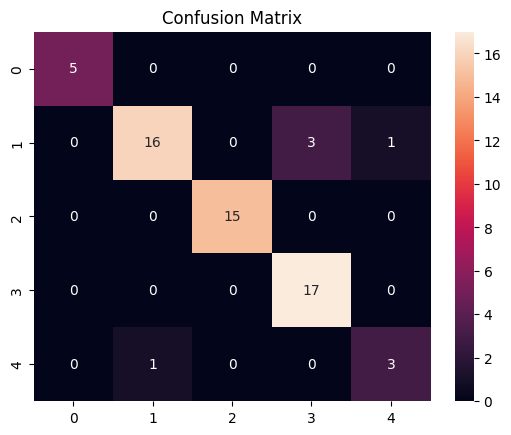

c:\Users\rosha\Documents\traffic_new\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


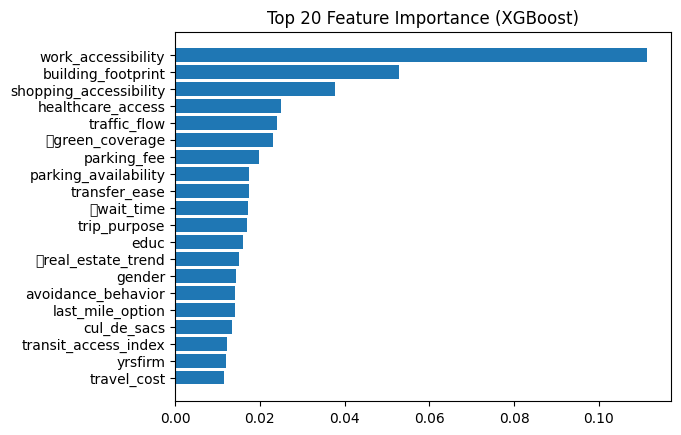


✅ Saved: feature_analysis.xlsx


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("mode_choice_data.csv")

# =========================
# 2. SPLIT FEATURES / TARGET
# =========================
X = df.drop(columns=["travel_mode"])
y = df["travel_mode"]

# Fix labels for XGBoost (VERY IMPORTANT)
y = y - y.min()

# =========================
# 3. HANDLE MISSING VALUES
# =========================
X = X.fillna(X.median(numeric_only=True))

# =========================
# 4. REMOVE HIGHLY CORRELATED FEATURES
# =========================
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

print(f"Removing {len(to_drop)} highly correlated features")

X = X.drop(columns=to_drop)

# =========================
# 5. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 6. TRAIN XGBOOST
# =========================
model = XGBClassifier(
    eval_metric="mlogloss",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# =========================
# 7. EVALUATION
# =========================
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# =========================
# 8. FEATURE IMPORTANCE (XGBoost)
# =========================
importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

# Plot Top 20
plt.figure()
plt.barh(
    feature_importance_df["feature"][:20][::-1],
    feature_importance_df["importance"][:20][::-1]
)
plt.title("Top 20 Feature Importance (XGBoost)")
plt.show()

with pd.ExcelWriter("feature_analysis.xlsx") as writer:
    
    # XGBoost Feature Importance
    feature_importance_df.to_excel(
        writer, sheet_name="XGB Importance", index=False
    )
print("\n✅ Saved: feature_analysis.xlsx")

Removing 2 highly correlated features

Accuracy: 0.5245901639344263

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       0.43      0.45      0.44        20
           2       0.50      0.40      0.44        15
           3       0.56      0.82      0.67        17
           4       0.00      0.00      0.00         4

    accuracy                           0.52        61
   macro avg       0.50      0.45      0.46        61
weighted avg       0.50      0.52      0.50        61



c:\Users\rosha\Documents\traffic_new\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rosha\Documents\traffic_new\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rosha\Documents\traffic_new\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

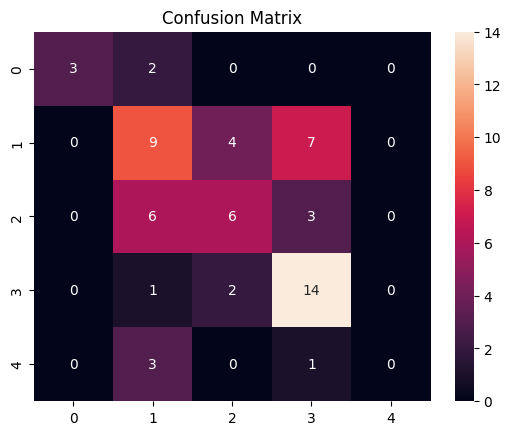

c:\Users\rosha\Documents\traffic_new\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


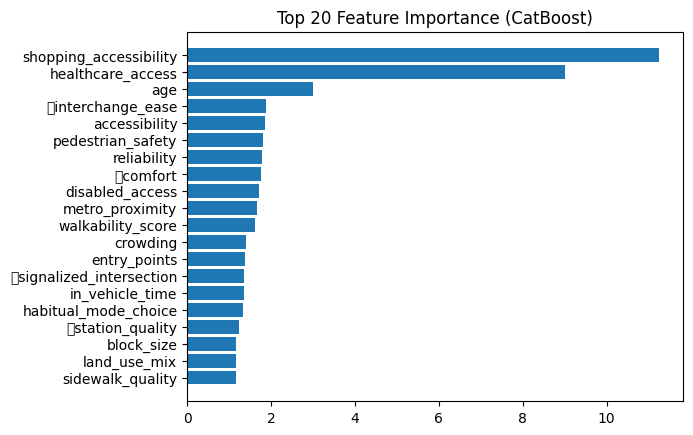


✅ Saved: feature_analysis_catboost.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from catboost import CatBoostClassifier

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("mode_choice_data.csv")

# =========================
# 2. SPLIT FEATURES / TARGET
# =========================
X = df.drop(columns=["travel_mode"])
y = df["travel_mode"]

# Fix labels (CatBoost can handle, but keeping consistent)
y = y - y.min()

# =========================
# 3. HANDLE MISSING VALUES
# =========================
# CatBoost can handle missing values internally, but keeping consistency
X = X.fillna(X.median(numeric_only=True))

# =========================
# 4. REMOVE HIGHLY CORRELATED FEATURES
# =========================
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

print(f"Removing {len(to_drop)} highly correlated features")

remove_column = ["id", "work_accessibility", "yrsfirm", "cusinter"]

to_drop = to_drop + remove_column

X = X.drop(columns=to_drop)

# =========================
# 5. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 6. TRAIN CATBOOST
# =========================
model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function='MultiClass',
    eval_metric='MultiClass',
    random_seed=42,
    verbose=0
)

model.fit(X_train, y_train)

# =========================
# 7. EVALUATION
# =========================
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# =========================
# 8. FEATURE IMPORTANCE (CATBOOST)
# =========================
importance = model.get_feature_importance()

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

# Plot Top 20
plt.figure()
plt.barh(
    feature_importance_df["feature"][:20][::-1],
    feature_importance_df["importance"][:20][::-1]
)
plt.title("Top 20 Feature Importance (CatBoost)")
plt.show()

# =========================
# 9. SAVE TO EXCEL
# =========================
with pd.ExcelWriter("feature_analysis_catboost.xlsx") as writer:
    
    feature_importance_df.to_excel(
        writer, sheet_name="CatBoost Importance", index=False
    )
    
    pd.DataFrame(to_drop, columns=["Dropped Features"]).to_excel(
        writer, sheet_name="Dropped Features", index=False
    )

print("\n✅ Saved: feature_analysis_catboost.xlsx")

In [ ]:
df["mixed_use_zoning"].value_counts()

fare_integration
6    119
7     88
5     55
4     31
3     12
Name: count, dtype: int64

Dropped 2 correlated features

Top 20 Features:
 ['work_accessibility', 'shopping_accessibility', 'healthcare_access', 'id', 'cusinter', 'age', 'reliability', 'entry_points', 'crossing_facility', 'pedestrian_safety', 'service_frequency', 'station_spacing', 'air_quality', '\tinterchange_ease', '\tcomfort', 'accessibility', 'block_size', 'disabled_access', '\treal_estate_trend', 'walkability_score']


c:\Users\rosha\Documents\traffic_new\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


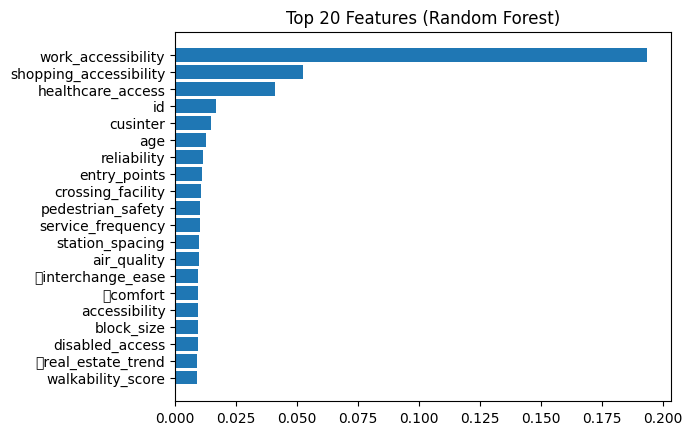


Accuracy: 0.8688524590163934

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.80      0.80      0.80        20
           2       1.00      1.00      1.00        15
           3       0.84      0.94      0.89        17
           4       0.50      0.25      0.33         4

    accuracy                           0.87        61
   macro avg       0.83      0.80      0.80        61
weighted avg       0.86      0.87      0.86        61



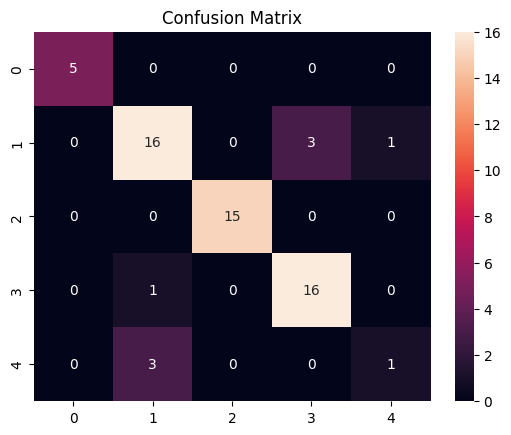

c:\Users\rosha\Documents\traffic_new\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


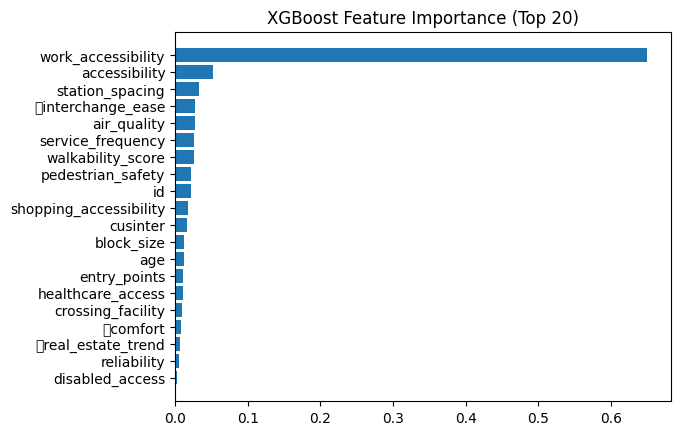


✅ Saved: rf_xgb_feature_pipeline.xlsx


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("mode_choice_data.csv")

# =========================
# 2. SPLIT FEATURES / TARGET
# =========================
X = df.drop(columns=["travel_mode"])
y = df["travel_mode"]

# Fix labels for XGBoost
y = y - y.min()

# =========================
# 3. HANDLE MISSING VALUES
# =========================
X = X.fillna(X.median(numeric_only=True))

# =========================
# 4. REMOVE HIGH CORRELATED FEATURES
# =========================
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
X = X.drop(columns=to_drop)

print(f"Dropped {len(to_drop)} correlated features")

# =========================
# 5. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 6. RANDOM FOREST FEATURE SELECTION
# =========================
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Feature importance
rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

# Select top 20 features
top_features = rf_importance["feature"].head(20).tolist()

print("\nTop 20 Features:\n", top_features)

# Plot RF importance
plt.figure()
plt.barh(rf_importance["feature"][:20][::-1],
         rf_importance["importance"][:20][::-1])
plt.title("Top 20 Features (Random Forest)")
plt.show()

# =========================
# 7. TRAIN XGBOOST ON TOP FEATURES
# =========================
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

xgb_model = XGBClassifier(
    eval_metric="mlogloss",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train_top, y_train)

# =========================
# 8. EVALUATION
# =========================
y_pred = xgb_model.predict(X_test_top)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# =========================
# 9. XGBOOST FEATURE IMPORTANCE
# =========================
importance = xgb_model.feature_importances_

xgb_importance_df = pd.DataFrame({
    "feature": top_features,
    "importance": importance
}).sort_values(by="importance", ascending=False)

plt.figure()
plt.barh(xgb_importance_df["feature"][::-1],
         xgb_importance_df["importance"][::-1])
plt.title("XGBoost Feature Importance (Top 20)")
plt.show()

# =========================
# 10. SAVE TO EXCEL
# =========================
with pd.ExcelWriter("rf_xgb_feature_pipeline.xlsx") as writer:
    
    rf_importance.to_excel(writer, sheet_name="RF Importance", index=False)
    
    xgb_importance_df.to_excel(writer, sheet_name="XGB Importance", index=False)
    
    pd.DataFrame(top_features, columns=["Top Features"]).to_excel(
        writer, sheet_name="Selected Features", index=False
    )

print("\n✅ Saved: rf_xgb_feature_pipeline.xlsx")


Top 20 features:
 ['work_accessibility', 'educ', 'shopping_accessibility', 'gender', 'healthcare_access', '\tgreen_coverage', '\treal_time_info', 'avoidance_behavior', 'income', 'accessibility', 'daily_trip_count', 'job_density', 'route_directness', 'network_connectivity', 'transit_access_index', 'transit_catchment', 'metro_proximity', 'air_quality', 'reliability', 'permit_parking', '\tshelter_availability', 'crossing_facility', 'noise_level', 'walkability_score', 'fare_integration', 'crowding', '\tland_value', 'habitual_mode_choice', 'development_density', 'trip_purpose']

Accuracy: 0.9016393442622951

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.89      0.80      0.84        20
           2       1.00      1.00      1.00        15
           3       0.85      1.00      0.92        17
           4       0.67      0.50      0.57         4

    accuracy                          

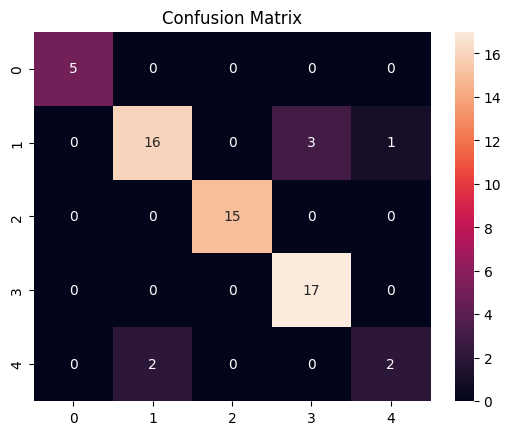

c:\Users\rosha\Documents\traffic_new\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


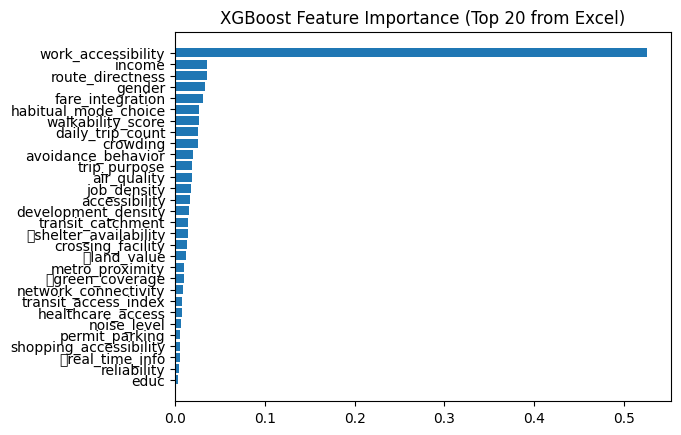

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("mode_choice_data.csv")

# =========================
# 2. LOAD FEATURE IMPORTANCE FROM EXCEL
# =========================
# Assuming sheet name = "Feature Importance"
feature_df = pd.read_excel("feature_analysis.xlsx")

# Select TOP 20 features
top_features = feature_df.sort_values(by="importance", ascending=False)["feature"].head(30).tolist()

print("\nTop 20 features:\n", top_features)

# =========================
# 3. PREPARE DATA
# =========================
X = df[top_features]
y = df["travel_mode"]

# Fix labels for XGBoost
y = y - y.min()

# Handle missing values
X = X.fillna(X.median(numeric_only=True))

# =========================
# 4. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 5. TRAIN XGBOOST
# =========================
model = XGBClassifier(
    eval_metric="mlogloss",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

# =========================
# 6. EVALUATION
# =========================
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# =========================
# 7. FEATURE IMPORTANCE (XGBOOST)
# =========================
importance = model.feature_importances_

importance_df = pd.DataFrame({
    "feature": top_features,
    "importance": importance
}).sort_values(by="importance", ascending=False)

plt.figure()
plt.barh(importance_df["feature"][::-1],
         importance_df["importance"][::-1])
plt.title("XGBoost Feature Importance (Top 20 from Excel)")
plt.show()

Removing 2 highly correlated features

Accuracy: 0.9016393442622951

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.89      0.80      0.84        20
           2       1.00      1.00      1.00        15
           3       0.84      0.94      0.89        17
           4       0.75      0.75      0.75         4

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



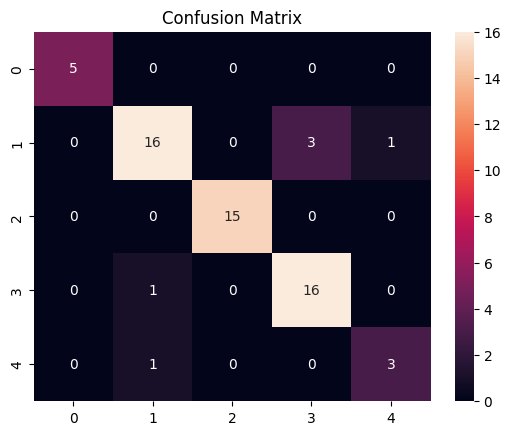

c:\Users\rosha\Documents\traffic_new\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


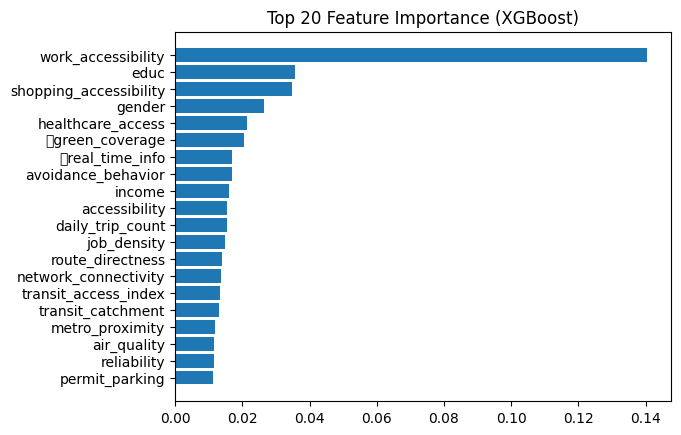


✅ Saved: feature_analysis.xlsx


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("mode_choice_data.csv")

# =========================
# 2. SPLIT FEATURES / TARGET
# =========================
X = df.drop(columns=["travel_mode"])
y = df["travel_mode"]

# Fix labels for XGBoost (VERY IMPORTANT)
y = y - y.min()

# =========================
# 3. HANDLE MISSING VALUES
# =========================
X = X.fillna(X.median(numeric_only=True))

# =========================
# 4. REMOVE HIGHLY CORRELATED FEATURES
# =========================
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

print(f"Removing {len(to_drop)} highly correlated features")

X = X.drop(columns=to_drop)

# =========================
# 5. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 6. TRAIN XGBOOST
# =========================
model = XGBClassifier(
    eval_metric="mlogloss",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# =========================
# 7. EVALUATION
# =========================
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# =========================
# 8. FEATURE IMPORTANCE (XGBoost)
# =========================
importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

# Plot Top 20
plt.figure()
plt.barh(
    feature_importance_df["feature"][:20][::-1],
    feature_importance_df["importance"][:20][::-1]
)
plt.title("Top 20 Feature Importance (XGBoost)")
plt.show()

with pd.ExcelWriter("feature_analysis.xlsx") as writer:
    
    # XGBoost Feature Importance
    feature_importance_df.to_excel(
        writer, sheet_name="XGB Importance", index=False
    )
print("\n✅ Saved: feature_analysis.xlsx")